In [1]:
import dask
from dask.distributed import Client, wait
from dask import delayed

client = Client()

client

/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/distributed/node.py:182: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 36895 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/36895/status,
Dashboard: /proxy/36895/status,Workers: 7
Total threads: 14,Total memory: 63.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:42807,Workers: 7
Dashboard: /proxy/36895/status,Total threads: 14
Started: Just now,Total memory: 63.00 GiB
Comm: tcp://127.0.0.1:35961,Total threads: 2
Dashboard: /proxy/33499/status,Memory: 9.00 GiB
Nanny: tcp://127.0.0.1:41575,


In [2]:
#import all the stuff
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib
import xclim.indices
from datetime import timedelta
import cartopy.crs as ccrs
import cartopy as cart
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

In [3]:
vpd_data = xr.open_dataset("/g/data/ia39/ncra/bushfire/vpd/ACCESS-ESM1-5/ssp370/r6i1p1f1/BARPA-R/v1-r1/day/ssp370_ACCESS-ESM1-5_gwl3.0_vpd.nc")['vpd']

In [4]:
vpd_data

<xarray.DataArray 'vpd' (time: 7305, lat: 691, lon: 886)> Size: 18GB
[4472310930 values with dtype=float32]
Coordinates:
  * lat      (lat) float64 6kB -44.5 -44.45 -44.4 -44.35 ... -10.1 -10.05 -10.0
  * lon      (lon) float64 7kB 112.0 112.0 112.1 112.2 ... 156.2 156.2 156.2
  * time     (time) datetime64[ns] 58kB 2062-01-01T12:00:00 ... 2081-12-31T12...
Attributes:
    long_name:      Daily maximum vapour dressure deficit computed from tasma...
    standard_name:  vpd
    units:          hPa

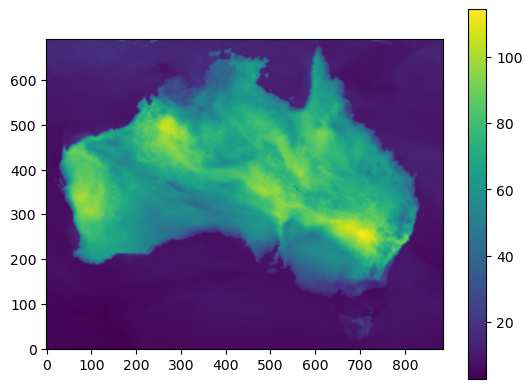

In [5]:
plt.imshow(vpd_data[0], origin='lower')
plt.colorbar()

In [6]:
mean_vpd_data = xr.open_dataset("/g/data/ia39/ncra/bushfire/vpd/monthly_mean/gwl2.0_monthly_mean_vpd_ACCESS-ESM1-5_ssp370_r6i1p1f1.nc")['monthly_mean_vpd']

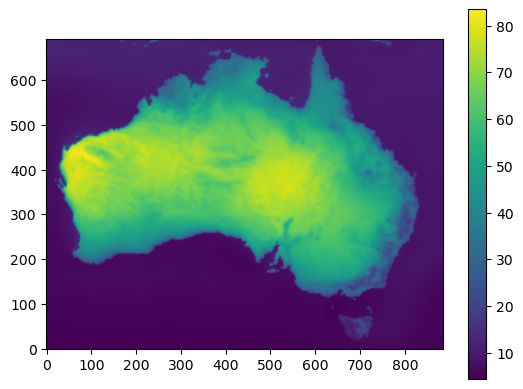

In [7]:
plt.imshow(mean_vpd_data[0], origin='lower')
plt.colorbar()

In [8]:
mean_vpd_data

<xarray.DataArray 'monthly_mean_vpd' (month: 12, lat: 691, lon: 886)> Size: 29MB
[7346712 values with dtype=float32]
Coordinates:
  * lat      (lat) float64 6kB -44.5 -44.45 -44.4 -44.35 ... -10.1 -10.05 -10.0
  * lon      (lon) float64 7kB 112.0 112.0 112.1 112.2 ... 156.2 156.2 156.2
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Attributes:
    long_name:      Monthly mean vapour dressure deficit computed from tasmax...
    standard_name:  monthly_mean_vpd
    units:          hPa

In [9]:
gwl30_mean_vpr_data = xr.open_dataset("/g/data/ia39/ncra/bushfire/vpd/monthly_mean/gwl3.0_monthly_mean_vpd_ACCESS-ESM1-5_ssp370_r6i1p1f1.nc")['monthly_mean_vpd']
gwl20_mean_vpr_data = xr.open_dataset("/g/data/ia39/ncra/bushfire/vpd/monthly_mean/gwl2.0_monthly_mean_vpd_ACCESS-ESM1-5_ssp370_r6i1p1f1.nc")['monthly_mean_vpd']
gwl15_mean_vpr_data = xr.open_dataset("/g/data/ia39/ncra/bushfire/vpd/monthly_mean/gwl1.5_monthly_mean_vpd_ACCESS-ESM1-5_ssp370_r6i1p1f1.nc")['monthly_mean_vpd']
gwl12_mean_vpr_data = xr.open_dataset("/g/data/ia39/ncra/bushfire/vpd/monthly_mean/gwl1.2_monthly_mean_vpd_ACCESS-ESM1-5_ssp370_r6i1p1f1.nc")['monthly_mean_vpd']


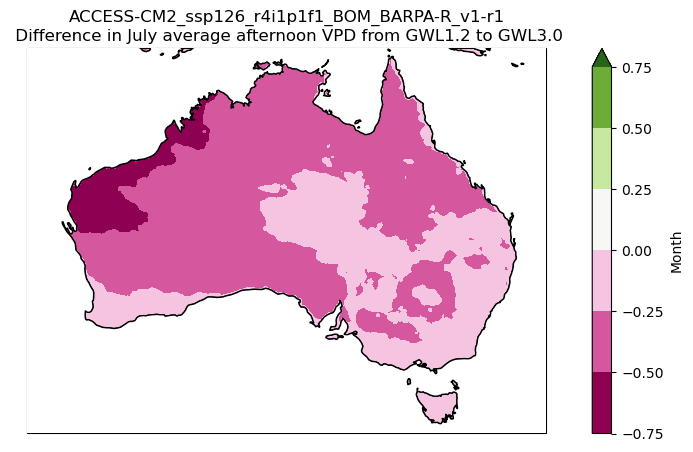

In [15]:
months = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
m = 6

fig = plt.figure(figsize=[12,5])
ax = fig.add_subplot(111, projection=ccrs.PlateCarree(central_longitude=180))

(gwl12_mean_vpr_data[m] - gwl30_mean_vpr_data[m]).plot.contourf(ax=ax,
                  extend='max',
                  transform=ccrs.PlateCarree(),
                  cbar_kwargs={'label': 'Month'},
                  cmap='PiYG'
                  )

month = months[m]
ax.coastlines()
ax.add_feature(cart.feature.OCEAN, zorder=100, edgecolor='black', facecolor='white')
title = 'ACCESS-CM2_ssp126_r4i1p1f1_BOM_BARPA-R_v1-r1\n Difference in %s average afternoon VPD from GWL1.2 to GWL3.0' %month
ax.set_title(title)

plt.show()